# Robustness Extension: Tree-Based Classifiers (RF + XGBoost)

Standalone extension to `robustness_study.ipynb` for the LNCS submission.

**New contributions:**
- RF and XGBoost evaluated alongside MLP baselines
- ZOO black-box attack (finite-difference L∞, Chen et al. 2017)
- TreeSHAP attribution drift (exact, via `TreeExplainer`)
- Explainability Stability Index (ESI) — explanation-domain analogue of RI
- Cross-model comparative table and figures

MLP baseline RI values are imported as constants from the original notebook results.


In [1]:
import importlib, subprocess, sys
if importlib.util.find_spec("xgboost") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost", "-q"])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import resample
import xgboost as xgb

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)
print(f"numpy {np.__version__}  |  xgboost {xgb.__version__}  |  shap {shap.__version__}")


numpy 2.4.6  |  xgboost 3.3.0  |  shap 0.52.0


In [2]:
df = pd.read_csv("Phishing_Legitimate_full.csv")
print("Phishing dataset:", df.shape)

y_p = df["CLASS_LABEL"].values
X_p = df.drop(columns=["id", "CLASS_LABEL"], errors="ignore").values
feature_names_phish = list(df.drop(columns=["id", "CLASS_LABEL"], errors="ignore").columns)

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_p, y_p, test_size=0.2, random_state=42, stratify=y_p)
scaler_p = StandardScaler().fit(X_train_p)
X_train_p = scaler_p.transform(X_train_p)
X_test_p  = scaler_p.transform(X_test_p)
print(f"Train: {X_train_p.shape}  Test: {X_test_p.shape}")


Phishing dataset: (10000, 50)
Train: (8000, 48)  Test: (2000, 48)


In [3]:
df_unsw = pd.read_csv("UNSW_NB15_training-set.csv")
df_unsw = df_unsw.drop(columns=["srcip", "dstip", "attack_cat"], errors="ignore")
for c in df_unsw.select_dtypes("object").columns:
    df_unsw[c] = LabelEncoder().fit_transform(df_unsw[c])
print("UNSW-NB15 dataset:", df_unsw.shape)

y_u = df_unsw["label"].values
X_u = df_unsw.drop(columns=["label"]).values
feature_names_unsw = list(df_unsw.drop(columns=["label"]).columns)

X_train_u, X_test_u, y_train_u, y_test_u = train_test_split(
    X_u, y_u, test_size=0.2, random_state=42)
scaler_u = StandardScaler().fit(X_train_u)
X_train_u = scaler_u.transform(X_train_u)
X_test_u  = scaler_u.transform(X_test_u)
print(f"Train: {X_train_u.shape}  Test: {X_test_u.shape}")


UNSW-NB15 dataset: (82332, 44)
Train: (65865, 43)  Test: (16467, 43)


In [4]:
# MLP baseline RI values from robustness_study.ipynb — used in comparison table.
# Re-run the original notebook to refresh these if needed.
MLP_RESULTS = {
    "Phishing": {"acc_clean": 0.857, "RI_fgsm": 0.610, "RI_pgd": 0.725},
    "UNSW-NB15": {"acc_clean": 0.774, "RI_fgsm": 0.692, "RI_pgd": 0.733},
}
print("MLP baseline reference values loaded.")


MLP baseline reference values loaded.


In [5]:
print("Training RF on Phishing...")
rf_phish = RandomForestClassifier(n_estimators=200, max_depth=12, n_jobs=-1, random_state=42)
rf_phish.fit(X_train_p, y_train_p)
print(f"  RF  clean acc: {rf_phish.score(X_test_p, y_test_p):.4f}")

print("Training XGBoost on Phishing...")
xgb_phish = xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, eval_metric="logloss",
    random_state=42, verbosity=0)
xgb_phish.fit(X_train_p, y_train_p)
print(f"  XGB clean acc: {xgb_phish.score(X_test_p, y_test_p):.4f}")


Training RF on Phishing...
  RF  clean acc: 0.9820
Training XGBoost on Phishing...
  XGB clean acc: 0.9865


In [6]:
print("Training RF on UNSW-NB15...")
rf_unsw = RandomForestClassifier(n_estimators=200, max_depth=12, n_jobs=-1, random_state=42)
rf_unsw.fit(X_train_u, y_train_u)
print(f"  RF  clean acc: {rf_unsw.score(X_test_u, y_test_u):.4f}")

print("Training XGBoost on UNSW-NB15...")
xgb_unsw = xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, eval_metric="logloss",
    random_state=42, verbosity=0)
xgb_unsw.fit(X_train_u, y_train_u)
print(f"  XGB clean acc: {xgb_unsw.score(X_test_u, y_test_u):.4f}")


Training RF on UNSW-NB15...
  RF  clean acc: 0.9970
Training XGBoost on UNSW-NB15...
  XGB clean acc: 0.9998


In [7]:
# ZOO (Zeroth-Order Optimization) black-box attack — Chen et al. 2017.
# Approximates the gradient via per-feature finite differences, then applies
# an FGSM or PGD step. Works on any model exposing predict_proba().

def _xent_loss(proba, y):
    return -np.log(np.clip(proba[np.arange(len(y)), y], 1e-10, 1.0))

def zoo_fgsm(predict_proba_fn, X, y, epsilon, delta=1e-3):
    # Single-step finite-difference attack (black-box FGSM analogue).
    # Cost: d+1 batched model calls.
    n, d = X.shape
    base_loss = _xent_loss(predict_proba_fn(X), y)
    grad_est = np.zeros_like(X)
    for j in range(d):
        X_plus = X.copy(); X_plus[:, j] += delta
        grad_est[:, j] = (_xent_loss(predict_proba_fn(X_plus), y) - base_loss) / delta
    return X + epsilon * np.sign(grad_est)

def zoo_pgd(predict_proba_fn, X, y, epsilon, alpha=0.01, steps=5, delta=1e-3):
    # Multi-step finite-difference attack (black-box PGD analogue).
    # Cost: steps x (d+1) batched model calls.
    X_adv, X_orig = X.copy(), X.copy()
    for _ in range(steps):
        base_loss = _xent_loss(predict_proba_fn(X_adv), y)
        grad_est = np.zeros_like(X_adv)
        for j in range(X_adv.shape[1]):
            X_plus = X_adv.copy(); X_plus[:, j] += delta
            grad_est[:, j] = (_xent_loss(predict_proba_fn(X_plus), y) - base_loss) / delta
        X_adv = X_adv + alpha * np.sign(grad_est)
        X_adv = np.clip(X_adv, X_orig - epsilon, X_orig + epsilon)
    return X_adv

print("ZOO FGSM / ZOO PGD defined.")


ZOO FGSM / ZOO PGD defined.


In [8]:
EPSILONS = np.linspace(0, 0.3, 10)

def evaluate_robustness_tree(model, X_test_np, y_test_np,
                              dataset_name="dataset", n_eval=1000):
    # Stratified subsample for CPU tractability
    idx = resample(np.arange(len(X_test_np)), n_samples=n_eval,
                   stratify=y_test_np, random_state=42)
    X_sub, y_sub = X_test_np[idx], y_test_np[idx]
    fn = model.predict_proba

    acc_fgsm, acc_pgd = [], []
    print(f"\n=== {dataset_name} ({n_eval} samples) ===")
    for eps in EPSILONS:
        X_f = zoo_fgsm(fn, X_sub, y_sub, eps)
        X_p = zoo_pgd(fn, X_sub, y_sub, eps)
        acc_fgsm.append((model.predict(X_f) == y_sub).mean())
        acc_pgd.append((model.predict(X_p) == y_sub).mean())
        print(f"  eps={eps:.3f}  ZOO-FGSM={acc_fgsm[-1]:.3f}  ZOO-PGD={acc_pgd[-1]:.3f}")

    RI_fgsm = np.trapezoid(acc_fgsm, EPSILONS) / (EPSILONS[-1] - EPSILONS[0])
    RI_pgd  = np.trapezoid(acc_pgd,  EPSILONS) / (EPSILONS[-1] - EPSILONS[0])
    print(f"  RI_FGSM={RI_fgsm:.3f}  RI_PGD={RI_pgd:.3f}")

    return {"dataset": dataset_name, "acc_clean": model.score(X_sub, y_sub),
            "acc_fgsm": acc_fgsm, "acc_pgd": acc_pgd,
            "RI_fgsm": RI_fgsm, "RI_pgd": RI_pgd,
            "X_sub": X_sub, "y_sub": y_sub}

print("evaluate_robustness_tree defined.")


evaluate_robustness_tree defined.


In [9]:
res_rf_phish  = evaluate_robustness_tree(rf_phish,  X_test_p, y_test_p, "Phishing (RF)")
res_xgb_phish = evaluate_robustness_tree(xgb_phish, X_test_p, y_test_p, "Phishing (XGB)")



=== Phishing (RF) (1000 samples) ===
  eps=0.000  ZOO-FGSM=0.977  ZOO-PGD=0.977
  eps=0.033  ZOO-FGSM=0.871  ZOO-PGD=0.863
  eps=0.067  ZOO-FGSM=0.885  ZOO-PGD=0.878
  eps=0.100  ZOO-FGSM=0.930  ZOO-PGD=0.873
  eps=0.133  ZOO-FGSM=0.888  ZOO-PGD=0.857
  eps=0.167  ZOO-FGSM=0.903  ZOO-PGD=0.889
  eps=0.200  ZOO-FGSM=0.933  ZOO-PGD=0.890
  eps=0.233  ZOO-FGSM=0.925  ZOO-PGD=0.911
  eps=0.267  ZOO-FGSM=0.880  ZOO-PGD=0.926
  eps=0.300  ZOO-FGSM=0.939  ZOO-PGD=0.898
  RI_FGSM=0.908  RI_PGD=0.892

=== Phishing (XGB) (1000 samples) ===
  eps=0.000  ZOO-FGSM=0.981  ZOO-PGD=0.981
  eps=0.033  ZOO-FGSM=0.979  ZOO-PGD=0.979
  eps=0.067  ZOO-FGSM=0.979  ZOO-PGD=0.979
  eps=0.100  ZOO-FGSM=0.979  ZOO-PGD=0.979
  eps=0.133  ZOO-FGSM=0.978  ZOO-PGD=0.979
  eps=0.167  ZOO-FGSM=0.978  ZOO-PGD=0.979
  eps=0.200  ZOO-FGSM=0.978  ZOO-PGD=0.979
  eps=0.233  ZOO-FGSM=0.978  ZOO-PGD=0.979
  eps=0.267  ZOO-FGSM=0.978  ZOO-PGD=0.979
  eps=0.300  ZOO-FGSM=0.978  ZOO-PGD=0.979
  RI_FGSM=0.978  RI_PGD=0.979


In [10]:
res_rf_unsw  = evaluate_robustness_tree(rf_unsw,  X_test_u, y_test_u, "UNSW-NB15 (RF)")
res_xgb_unsw = evaluate_robustness_tree(xgb_unsw, X_test_u, y_test_u, "UNSW-NB15 (XGB)")



=== UNSW-NB15 (RF) (1000 samples) ===
  eps=0.000  ZOO-FGSM=0.998  ZOO-PGD=0.998
  eps=0.033  ZOO-FGSM=0.964  ZOO-PGD=0.970
  eps=0.067  ZOO-FGSM=0.959  ZOO-PGD=0.966
  eps=0.100  ZOO-FGSM=0.949  ZOO-PGD=0.970
  eps=0.133  ZOO-FGSM=0.948  ZOO-PGD=0.966
  eps=0.167  ZOO-FGSM=0.952  ZOO-PGD=0.970
  eps=0.200  ZOO-FGSM=0.947  ZOO-PGD=0.965
  eps=0.233  ZOO-FGSM=0.931  ZOO-PGD=0.966
  eps=0.267  ZOO-FGSM=0.908  ZOO-PGD=0.973
  eps=0.300  ZOO-FGSM=0.884  ZOO-PGD=0.969
  RI_FGSM=0.944  RI_PGD=0.970

=== UNSW-NB15 (XGB) (1000 samples) ===
  eps=0.000  ZOO-FGSM=0.999  ZOO-PGD=0.999
  eps=0.033  ZOO-FGSM=0.994  ZOO-PGD=0.996
  eps=0.067  ZOO-FGSM=0.994  ZOO-PGD=0.996
  eps=0.100  ZOO-FGSM=0.994  ZOO-PGD=0.996
  eps=0.133  ZOO-FGSM=0.994  ZOO-PGD=0.996
  eps=0.167  ZOO-FGSM=0.994  ZOO-PGD=0.996
  eps=0.200  ZOO-FGSM=0.994  ZOO-PGD=0.996
  eps=0.233  ZOO-FGSM=0.994  ZOO-PGD=0.996
  eps=0.267  ZOO-FGSM=0.994  ZOO-PGD=0.996
  eps=0.300  ZOO-FGSM=0.994  ZOO-PGD=0.996
  RI_FGSM=0.994  RI_PGD=0.996


In [11]:
def _extract_shap_class1(sv):
    # Normalize SHAP output across model/version differences:
    #   old SHAP + RF  -> list [class0_arr, class1_arr], each (n, d)
    #   new SHAP + RF  -> ndarray (n, d, n_classes)
    #   XGBoost        -> ndarray (n, d)
    if isinstance(sv, list):
        return sv[1]
    if sv.ndim == 3:
        return sv[:, :, 1]
    return sv  # already (n, d)

def compute_treeshap_drift(model, predict_proba_fn, X_sub, y_sub,
                           feature_names, top_k=10, attack_fn=None,
                           title="TreeSHAP Drift", save_path=None, show_plot=True):
    # Exact TreeSHAP attribution drift across ZOO perturbation levels.
    if attack_fn is None:
        attack_fn = zoo_fgsm

    explainer = shap.TreeExplainer(model)
    base_sv = _extract_shap_class1(explainer.shap_values(X_sub))  # (n, d)

    drift_matrix = []
    for eps in EPSILONS:
        X_adv = attack_fn(predict_proba_fn, X_sub, y_sub, eps)
        adv_sv = _extract_shap_class1(explainer.shap_values(X_adv))  # (n, d)
        drift_matrix.append(np.abs(adv_sv - base_sv).mean(axis=0))  # (d,)

    drift_matrix = np.stack(drift_matrix)       # (n_eps, d)
    drift_per_eps = drift_matrix.mean(axis=1)   # (n_eps,)

    top_idx = np.argsort(-drift_matrix.mean(axis=0))[:top_k]  # (top_k,) ints
    df_pivot = pd.DataFrame(
        drift_matrix[:, top_idx],
        index=[f"eps={e:.2f}" for e in EPSILONS],
        columns=[feature_names[i] for i in top_idx]
    )

    if save_path or show_plot:
        plt.figure(figsize=(8, 4))
        sns.heatmap(df_pivot, cmap="Reds", cbar_kws={"label": "delta_SHAP"})
        plt.title(title); plt.xlabel("Feature"); plt.ylabel("Perturbation (eps)")
        plt.tight_layout()
        if save_path: plt.savefig(save_path, dpi=300)
        if show_plot: plt.show()
        else: plt.close()

    return df_pivot, drift_matrix, drift_per_eps

print("compute_treeshap_drift defined.")


compute_treeshap_drift defined.


TreeSHAP drift — RF Phishing...


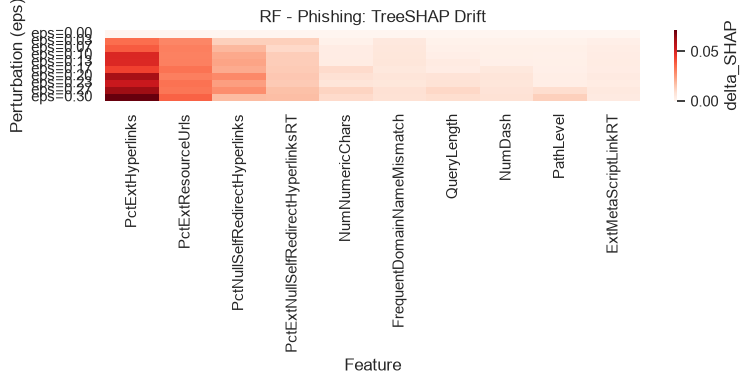

TreeSHAP drift — XGB Phishing...


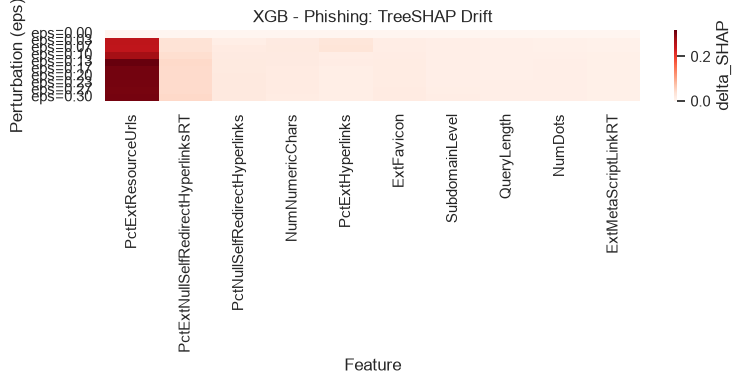

In [12]:
print("TreeSHAP drift — RF Phishing...")
_, _, rf_phish_drift_eps = compute_treeshap_drift(
    rf_phish, rf_phish.predict_proba,
    res_rf_phish["X_sub"], res_rf_phish["y_sub"],
    feature_names_phish, title="RF - Phishing: TreeSHAP Drift",
    save_path="treeshap_drift_rf_phish.png")

print("TreeSHAP drift — XGB Phishing...")
_, _, xgb_phish_drift_eps = compute_treeshap_drift(
    xgb_phish, xgb_phish.predict_proba,
    res_xgb_phish["X_sub"], res_xgb_phish["y_sub"],
    feature_names_phish, title="XGB - Phishing: TreeSHAP Drift",
    save_path="treeshap_drift_xgb_phish.png")


TreeSHAP drift — RF UNSW-NB15...


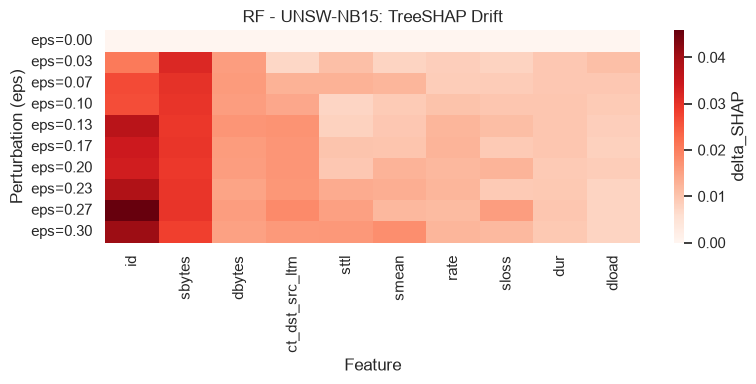

TreeSHAP drift — XGB UNSW-NB15...


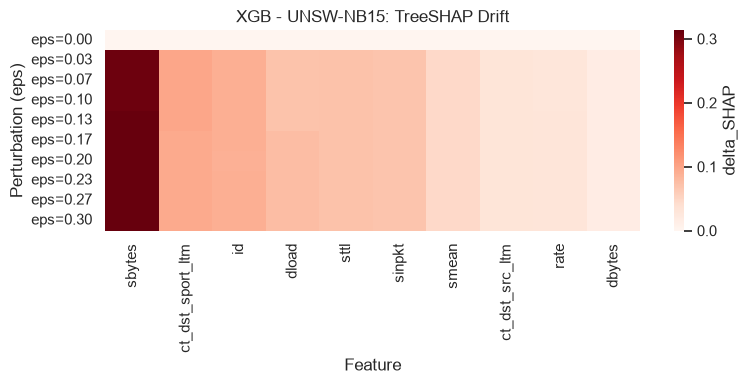

In [13]:
print("TreeSHAP drift — RF UNSW-NB15...")
_, _, rf_unsw_drift_eps = compute_treeshap_drift(
    rf_unsw, rf_unsw.predict_proba,
    res_rf_unsw["X_sub"], res_rf_unsw["y_sub"],
    feature_names_unsw, title="RF - UNSW-NB15: TreeSHAP Drift",
    save_path="treeshap_drift_rf_unsw.png")

print("TreeSHAP drift — XGB UNSW-NB15...")
_, _, xgb_unsw_drift_eps = compute_treeshap_drift(
    xgb_unsw, xgb_unsw.predict_proba,
    res_xgb_unsw["X_sub"], res_xgb_unsw["y_sub"],
    feature_names_unsw, title="XGB - UNSW-NB15: TreeSHAP Drift",
    save_path="treeshap_drift_xgb_unsw.png")


In [14]:
def compute_esi(drift_per_eps, epsilons):
    # Explainability Stability Index: 1 minus normalized AUC of SHAP-drift curve.
    # ESI=1: perfectly stable explanations. ESI=0: maximum instability.
    D_max = drift_per_eps[-1] if drift_per_eps[-1] > 0 else 1.0
    auc = np.trapezoid(drift_per_eps / D_max, epsilons) / (epsilons[-1] - epsilons[0])
    return round(float(1.0 - auc), 3)

esi_rf_phish  = compute_esi(rf_phish_drift_eps,  EPSILONS)
esi_xgb_phish = compute_esi(xgb_phish_drift_eps, EPSILONS)
esi_rf_unsw   = compute_esi(rf_unsw_drift_eps,   EPSILONS)
esi_xgb_unsw  = compute_esi(xgb_unsw_drift_eps,  EPSILONS)

print("ESI (higher = more stable explanations under attack):")
print(f"  RF   Phishing: {esi_rf_phish}   UNSW: {esi_rf_unsw}")
print(f"  XGB  Phishing: {esi_xgb_phish}   UNSW: {esi_xgb_unsw}")


ESI (higher = more stable explanations under attack):
  RF   Phishing: 0.287   UNSW: 0.167
  XGB  Phishing: 0.111   UNSW: 0.063


In [15]:
rows = [
    ("Phishing",  "MLP (baseline)",
     MLP_RESULTS["Phishing"]["acc_clean"],
     MLP_RESULTS["Phishing"]["RI_fgsm"],
     MLP_RESULTS["Phishing"]["RI_pgd"], "—"),
    ("Phishing",  "RF",
     res_rf_phish["acc_clean"],
     res_rf_phish["RI_fgsm"], res_rf_phish["RI_pgd"], esi_rf_phish),
    ("Phishing",  "XGBoost",
     res_xgb_phish["acc_clean"],
     res_xgb_phish["RI_fgsm"], res_xgb_phish["RI_pgd"], esi_xgb_phish),
    ("UNSW-NB15", "MLP (baseline)",
     MLP_RESULTS["UNSW-NB15"]["acc_clean"],
     MLP_RESULTS["UNSW-NB15"]["RI_fgsm"],
     MLP_RESULTS["UNSW-NB15"]["RI_pgd"], "—"),
    ("UNSW-NB15", "RF",
     res_rf_unsw["acc_clean"],
     res_rf_unsw["RI_fgsm"], res_rf_unsw["RI_pgd"], esi_rf_unsw),
    ("UNSW-NB15", "XGBoost",
     res_xgb_unsw["acc_clean"],
     res_xgb_unsw["RI_fgsm"], res_xgb_unsw["RI_pgd"], esi_xgb_unsw),
]

summary = pd.DataFrame(rows,
    columns=["Dataset", "Model", "Clean Acc", "RI_FGSM", "RI_PGD", "ESI"])
print("\n=== Cross-Model Robustness and ESI Comparison ===")
print(summary.to_string(index=False))
summary.to_csv("cross_model_robustness_summary.csv", index=False)
print("\nSaved: cross_model_robustness_summary.csv")



=== Cross-Model Robustness and ESI Comparison ===
  Dataset          Model  Clean Acc  RI_FGSM   RI_PGD    ESI
 Phishing MLP (baseline)      0.857 0.610000 0.725000      —
 Phishing             RF      0.977 0.908111 0.891611  0.287
 Phishing        XGBoost      0.981 0.978500 0.979111  0.111
UNSW-NB15 MLP (baseline)      0.774 0.692000 0.733000      —
UNSW-NB15             RF      0.998 0.944333 0.969944  0.167
UNSW-NB15        XGBoost      0.999 0.994278 0.996167  0.063

Saved: cross_model_robustness_summary.csv


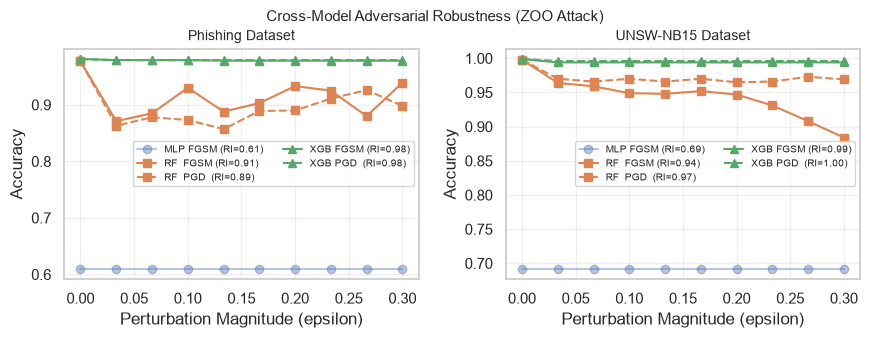

Saved: cross_model_robustness_curves.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), sharey=False)

def _plot_curves(ax, res_rf, res_xgb, mlp_ref, title):
    ax.plot(EPSILONS, mlp_ref["acc_fgsm"] if "acc_fgsm" in mlp_ref
            else [mlp_ref["RI_fgsm"]] * len(EPSILONS),
            "o-", color="C0", alpha=0.4, label=f"MLP FGSM (RI={mlp_ref['RI_fgsm']:.2f})")
    ax.plot(EPSILONS, res_rf["acc_fgsm"],  "s-",  color="C1",
            label=f"RF  FGSM (RI={res_rf['RI_fgsm']:.2f})")
    ax.plot(EPSILONS, res_rf["acc_pgd"],   "s--", color="C1",
            label=f"RF  PGD  (RI={res_rf['RI_pgd']:.2f})")
    ax.plot(EPSILONS, res_xgb["acc_fgsm"], "^-",  color="C2",
            label=f"XGB FGSM (RI={res_xgb['RI_fgsm']:.2f})")
    ax.plot(EPSILONS, res_xgb["acc_pgd"],  "^--", color="C2",
            label=f"XGB PGD  (RI={res_xgb['RI_pgd']:.2f})")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Perturbation Magnitude (epsilon)")
    ax.set_ylabel("Accuracy")
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)

_plot_curves(axes[0], res_rf_phish, res_xgb_phish, MLP_RESULTS["Phishing"], "Phishing Dataset")
_plot_curves(axes[1], res_rf_unsw,  res_xgb_unsw,  MLP_RESULTS["UNSW-NB15"], "UNSW-NB15 Dataset")

fig.suptitle("Cross-Model Adversarial Robustness (ZOO Attack)", fontsize=11)
fig.tight_layout(pad=1.5); fig.subplots_adjust(top=0.87)
plt.savefig("cross_model_robustness_curves.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: cross_model_robustness_curves.png")


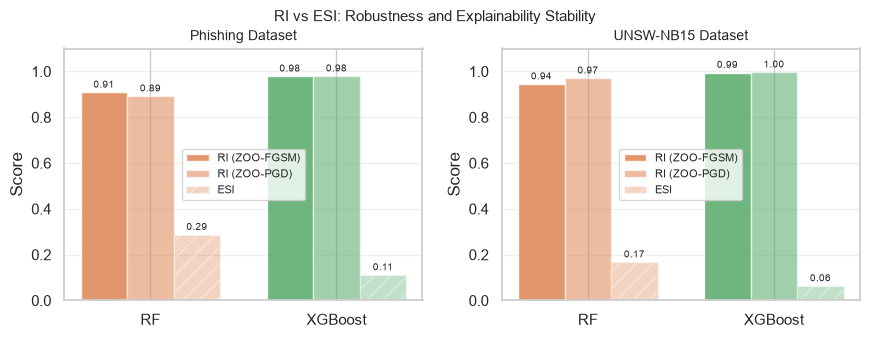

Saved: ri_esi_comparison.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

for ax, dataset, ri_f, ri_p, esi_vals, title in [
    (axes[0], "Phishing",
     [res_rf_phish["RI_fgsm"], res_xgb_phish["RI_fgsm"]],
     [res_rf_phish["RI_pgd"],  res_xgb_phish["RI_pgd"]],
     [esi_rf_phish, esi_xgb_phish],
     "Phishing Dataset"),
    (axes[1], "UNSW-NB15",
     [res_rf_unsw["RI_fgsm"],  res_xgb_unsw["RI_fgsm"]],
     [res_rf_unsw["RI_pgd"],   res_xgb_unsw["RI_pgd"]],
     [esi_rf_unsw,  esi_xgb_unsw],
     "UNSW-NB15 Dataset"),
]:
    models = ["RF", "XGBoost"]
    x = np.arange(len(models)); w = 0.25
    b1 = ax.bar(x - w,   ri_f,    w, label="RI (ZOO-FGSM)", color=["C1","C2"], alpha=0.85)
    b2 = ax.bar(x,       ri_p,    w, label="RI (ZOO-PGD)",  color=["C1","C2"], alpha=0.55)
    b3 = ax.bar(x + w,   esi_vals,w, label="ESI",           color=["C1","C2"], alpha=0.35, hatch="//")
    ax.set_xticks(x); ax.set_xticklabels(models)
    ax.set_ylim(0, 1.1); ax.set_ylabel("Score"); ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)
    for bars in [b1, b2, b3]:
        ax.bar_label(bars, fmt="%.2f", fontsize=7, padding=2)

fig.suptitle("RI vs ESI: Robustness and Explainability Stability", fontsize=11)
fig.tight_layout(pad=1.5); fig.subplots_adjust(top=0.87)
plt.savefig("ri_esi_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: ri_esi_comparison.png")
